# Lab 23: Line Charts - Data Visualization
## IBM Data Analytics Capstone Project 
### Objective: Track trends in compensation and job satisfaction across age groups and experience levels

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

age_order = ['Under 18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']

print("Dataset loaded! Shape:", df.shape)

Dataset loaded! Shape: (65437, 114)


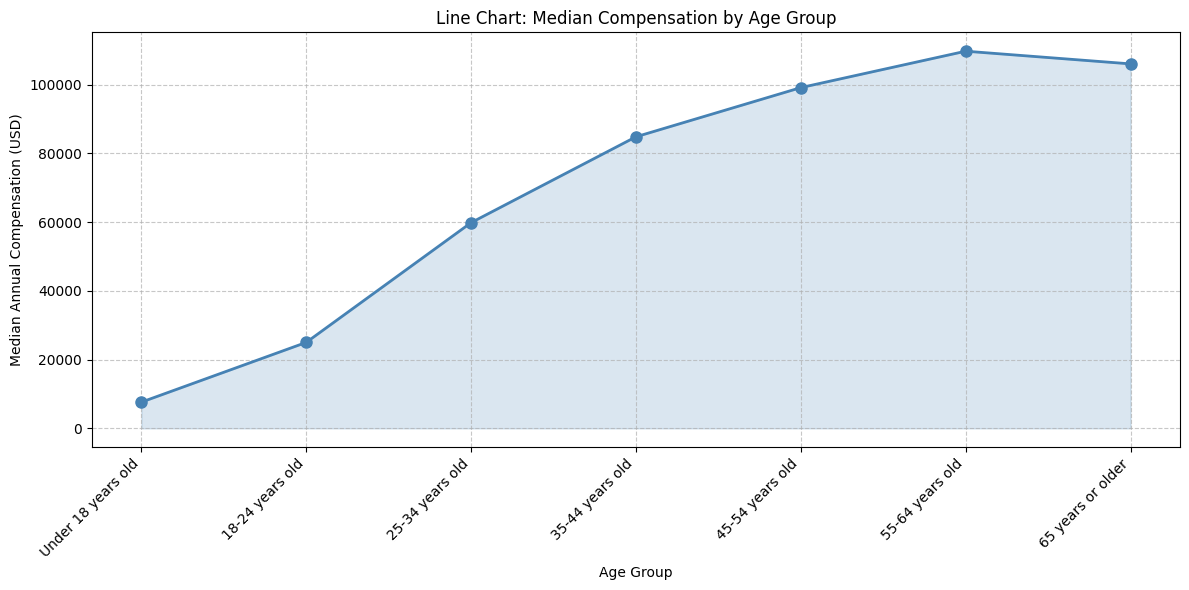

Compensation by age saved!
Age
Under 18 years old      7626.5
18-24 years old        25000.0
25-34 years old        59825.0
35-44 years old        84796.0
45-54 years old        99099.0
55-64 years old       109691.0
65 years or older     106000.0
Name: ConvertedCompYearly, dtype: float64


In [2]:
# Median compensation by age group
df_comp_age = df.groupby('Age')['ConvertedCompYearly'].median().reindex(age_order).dropna()

plt.figure(figsize=(12, 6))
plt.plot(df_comp_age.index, df_comp_age.values, 
         marker='o', color='steelblue', linewidth=2, markersize=8)
plt.fill_between(range(len(df_comp_age)), df_comp_age.values, alpha=0.2, color='steelblue')
plt.title('Line Chart: Median Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Annual Compensation (USD)')
plt.xticks(range(len(df_comp_age)), df_comp_age.index, rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('line_comp_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Compensation by age saved!")
print(df_comp_age)

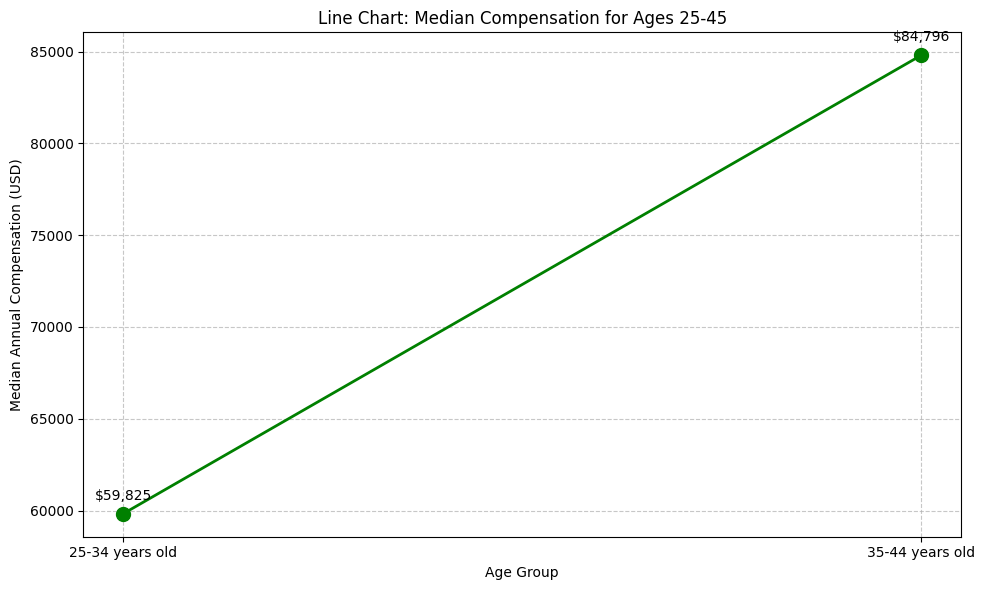

Compensation ages 25-45 saved!
Age
25-34 years old    59825.0
35-44 years old    84796.0
Name: ConvertedCompYearly, dtype: float64


In [3]:
# Filter ages 25-44
ages_25_45 = ['25-34 years old', '35-44 years old']
df_comp_25_45 = df[df['Age'].isin(ages_25_45)].groupby('Age')['ConvertedCompYearly'].median()

plt.figure(figsize=(10, 6))
plt.plot(df_comp_25_45.index, df_comp_25_45.values,
         marker='o', color='green', linewidth=2, markersize=10)
for i, (age, val) in enumerate(df_comp_25_45.items()):
    plt.annotate(f'${val:,.0f}', (age, val), 
                 textcoords="offset points", xytext=(0,10), ha='center')
plt.title('Line Chart: Median Compensation for Ages 25-45')
plt.xlabel('Age Group')
plt.ylabel('Median Annual Compensation (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('line_comp_25_45.png', dpi=150, bbox_inches='tight')
plt.show()
print("Compensation ages 25-45 saved!")
print(df_comp_25_45)

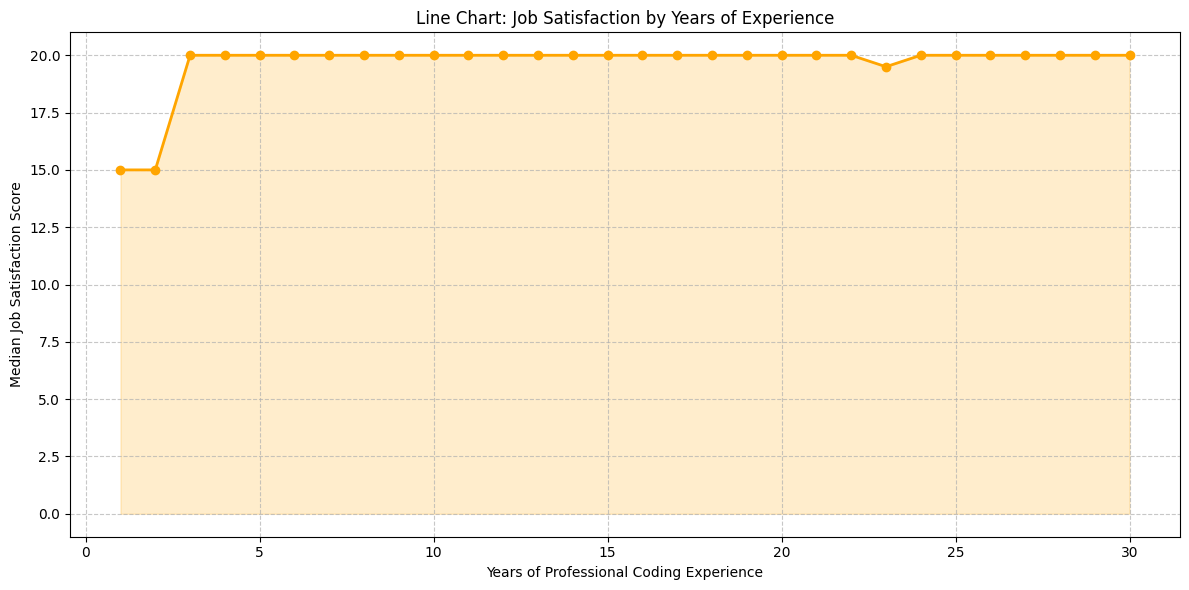

JobSat by experience saved!


In [4]:
# JobSat by YearsCodePro experience levels
df['YearsCodePro_Num'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df_jobsat_exp = df.groupby('YearsCodePro_Num')['JobSatPoints_6'].median().dropna()
df_jobsat_exp = df_jobsat_exp[df_jobsat_exp.index <= 30]  # cap at 30 years

plt.figure(figsize=(12, 6))
plt.plot(df_jobsat_exp.index, df_jobsat_exp.values,
         marker='o', color='orange', linewidth=2, markersize=6)
plt.fill_between(df_jobsat_exp.index, df_jobsat_exp.values, alpha=0.2, color='orange')
plt.title('Line Chart: Job Satisfaction by Years of Experience')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Median Job Satisfaction Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('line_jobsat_experience.png', dpi=150, bbox_inches='tight')
plt.show()
print("JobSat by experience saved!")

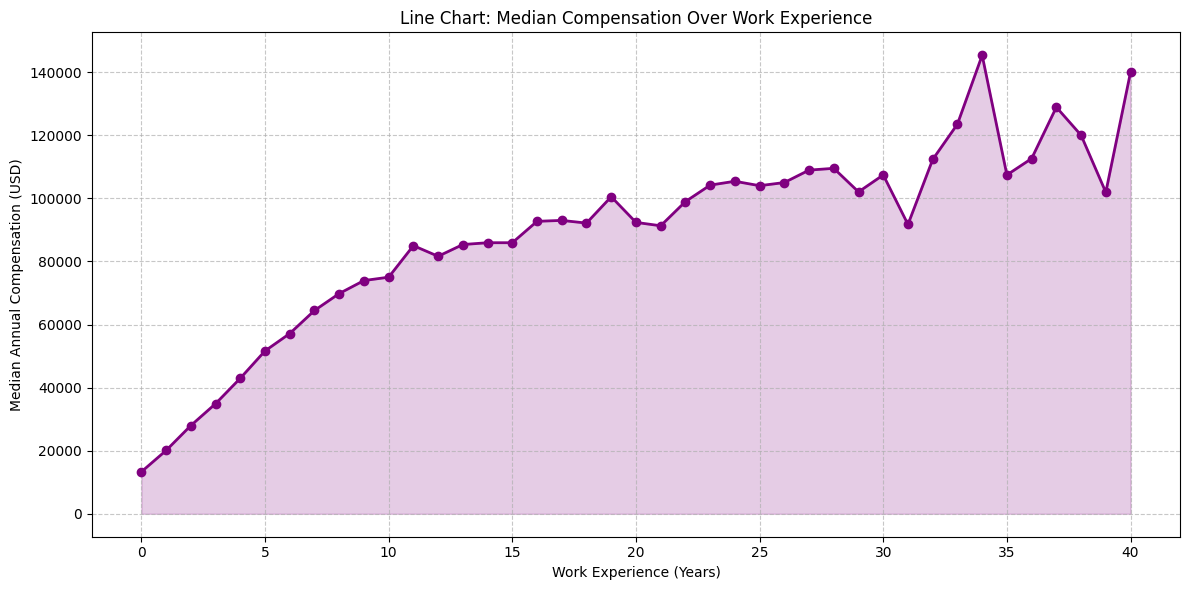

Compensation by WorkExp saved!


In [5]:
# Median compensation by WorkExp
df_comp_exp = df.groupby('WorkExp')['ConvertedCompYearly'].median().dropna()
df_comp_exp = df_comp_exp[df_comp_exp.index <= 40]

plt.figure(figsize=(12, 6))
plt.plot(df_comp_exp.index, df_comp_exp.values,
         marker='o', color='purple', linewidth=2, markersize=6)
plt.fill_between(df_comp_exp.index, df_comp_exp.values, alpha=0.2, color='purple')
plt.title('Line Chart: Median Compensation Over Work Experience')
plt.xlabel('Work Experience (Years)')
plt.ylabel('Median Annual Compensation (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('line_comp_workexp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Compensation by WorkExp saved!")

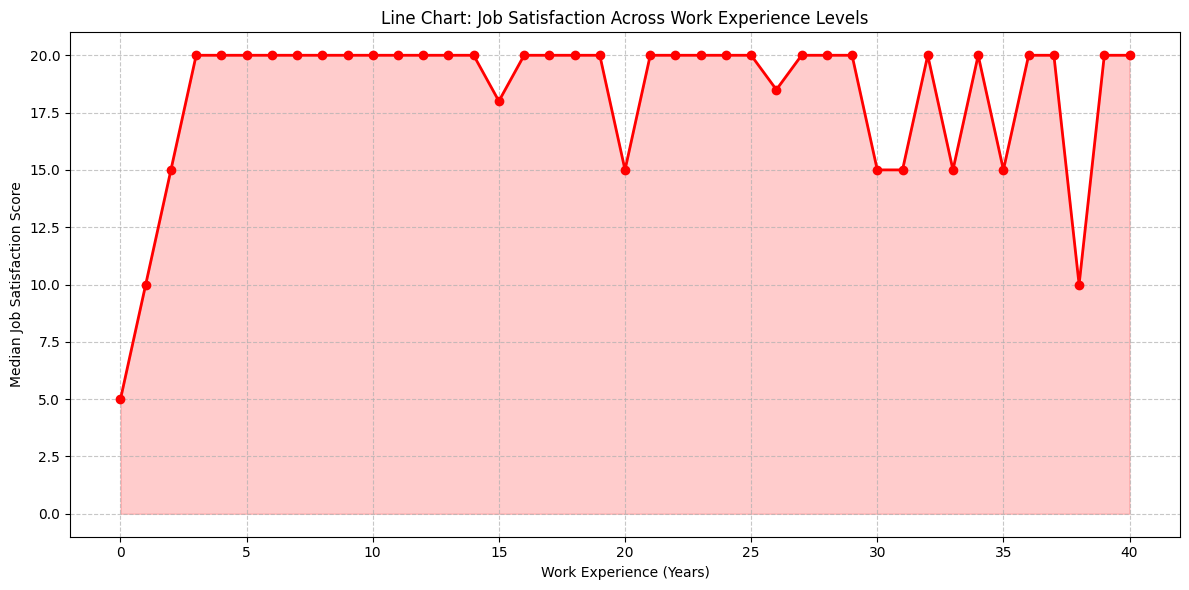

JobSat by WorkExp saved!


In [6]:
# JobSat across WorkExp levels
df_jobsat_workexp = df.groupby('WorkExp')['JobSatPoints_6'].median().dropna()
df_jobsat_workexp = df_jobsat_workexp[df_jobsat_workexp.index <= 40]

plt.figure(figsize=(12, 6))
plt.plot(df_jobsat_workexp.index, df_jobsat_workexp.values,
         marker='o', color='red', linewidth=2, markersize=6)
plt.fill_between(df_jobsat_workexp.index, df_jobsat_workexp.values, alpha=0.2, color='red')
plt.title('Line Chart: Job Satisfaction Across Work Experience Levels')
plt.xlabel('Work Experience (Years)')
plt.ylabel('Median Job Satisfaction Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('line_jobsat_workexp.png', dpi=150, bbox_inches='tight')
plt.show()
print("JobSat by WorkExp saved!")